# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [1]:
print("Hello World!")


Hello World!


In [2]:
pip install yfinance pandas matplotlib seaborn plotly numpy

  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 4.1 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.9 MB 3.1 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.9 MB 3.1 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.9 MB 3.3 MB/s eta 0:00:03
   ------------- -------------------------- 3.4/9.9 MB 3.4 MB/s eta 0:00:02
   ---------------- ----------------------- 4.2/9.9 MB 3.5 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.9 MB 3.6 MB/s eta 0:00:02
   ------------------------ --------------- 6.0/9.9 MB 3.6 MB/s eta 0:00:02
   ---------------------------- ----------- 7.1/9.9 MB 3.7 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 3.7 MB/s eta 0:00:01
   --------------------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
tickers = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'AAPL', 'MSFT']

data = yf.download(tickers, start='2022-01-01', end='2024-12-31')

close = data['Close']
print(close.head())
print("\nShape:", close.shape)

[*********************100%***********************]  5 of 5 completed


Ticker            AAPL      INFY.NS        MSFT  RELIANCE.NS       TCS.NS
Date                                                                     
2022-01-03  177.939713  1704.249390  323.160767  1093.780640  3386.358154
2022-01-04  175.681381  1704.878052  317.619476  1118.465088  3445.786865
2022-01-05  171.008270  1655.953003  305.426788  1123.697632  3424.676514
2022-01-06  168.153564  1631.849609  303.013306  1099.536499  3377.221436
2022-01-07  168.319763  1628.707520  303.167755  1108.409302  3418.067871

Shape: (776, 5)


Annualised Volatility:
Ticker
MSFT           0.281289
AAPL           0.274631
INFY.NS        0.239545
RELIANCE.NS    0.223971
TCS.NS         0.206956
dtype: float64


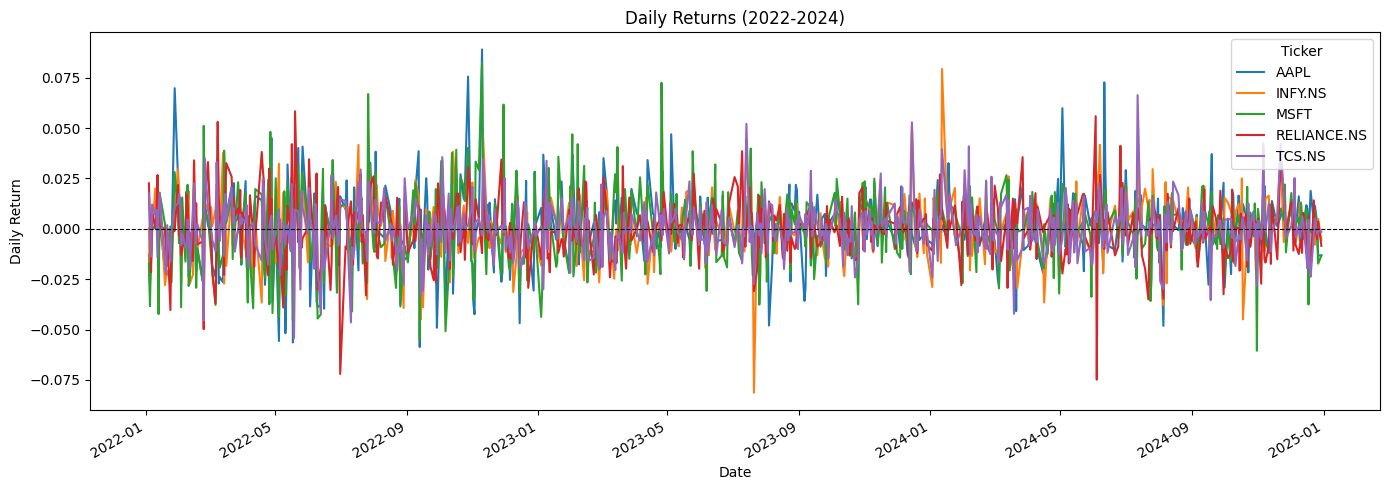

In [3]:
# Daily returns
returns = close.pct_change().dropna()

# Annualised volatility
volatility = returns.std() * np.sqrt(252)
print("Annualised Volatility:")
print(volatility.sort_values(ascending=False))

# Returns ka plot
returns.plot(figsize=(14, 5), title='Daily Returns (2022-2024)')
plt.ylabel('Daily Return')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

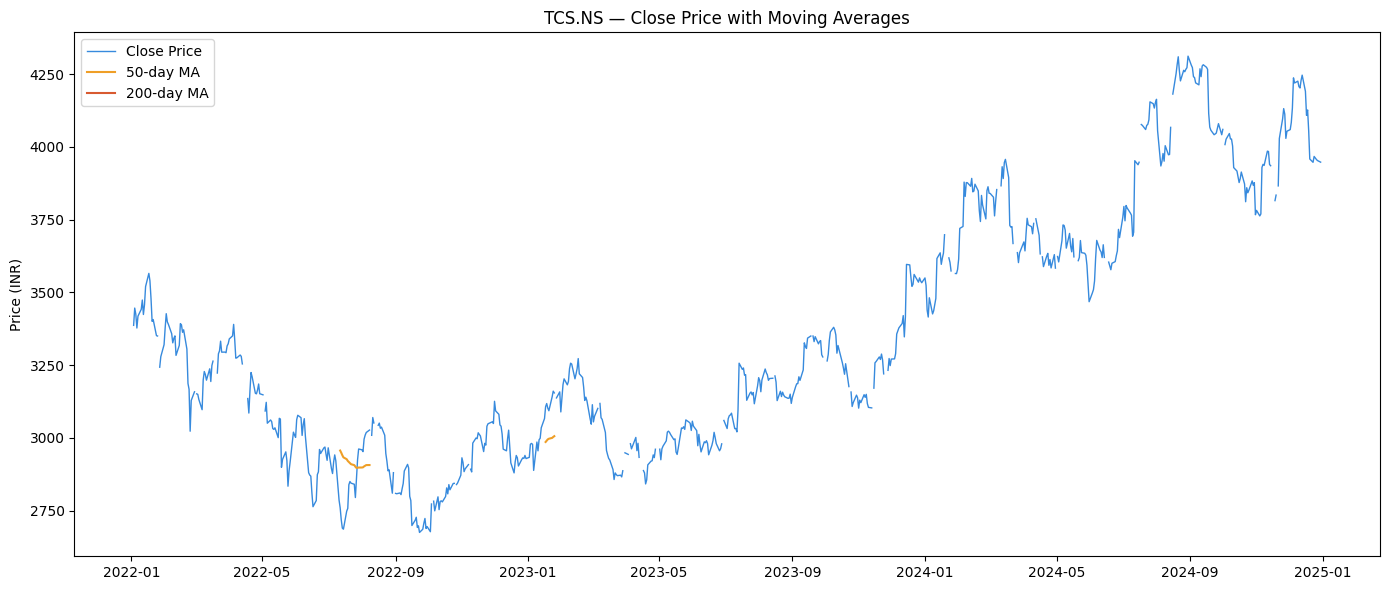

In [4]:
# TCS ka Moving Average
stock = 'TCS.NS'
df = close[[stock]].copy()

df['MA50']  = df[stock].rolling(50).mean()
df['MA200'] = df[stock].rolling(200).mean()

plt.figure(figsize=(14, 6))
plt.plot(df[stock],    label='Close Price', color='#378ADD', linewidth=1)
plt.plot(df['MA50'],   label='50-day MA',   color='#EF9F27', linewidth=1.5)
plt.plot(df['MA200'],  label='200-day MA',  color='#D85A30', linewidth=1.5)
plt.title('TCS.NS — Close Price with Moving Averages')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

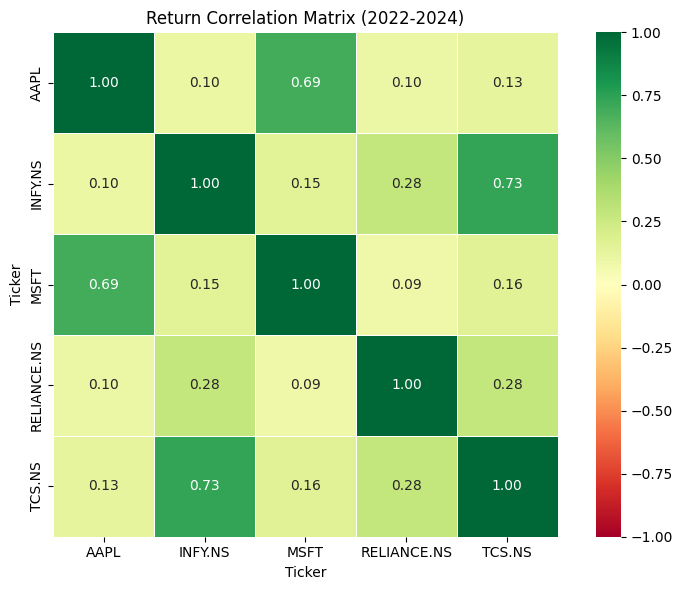

In [5]:
corr = returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Return Correlation Matrix (2022-2024)')
plt.tight_layout()
plt.show()

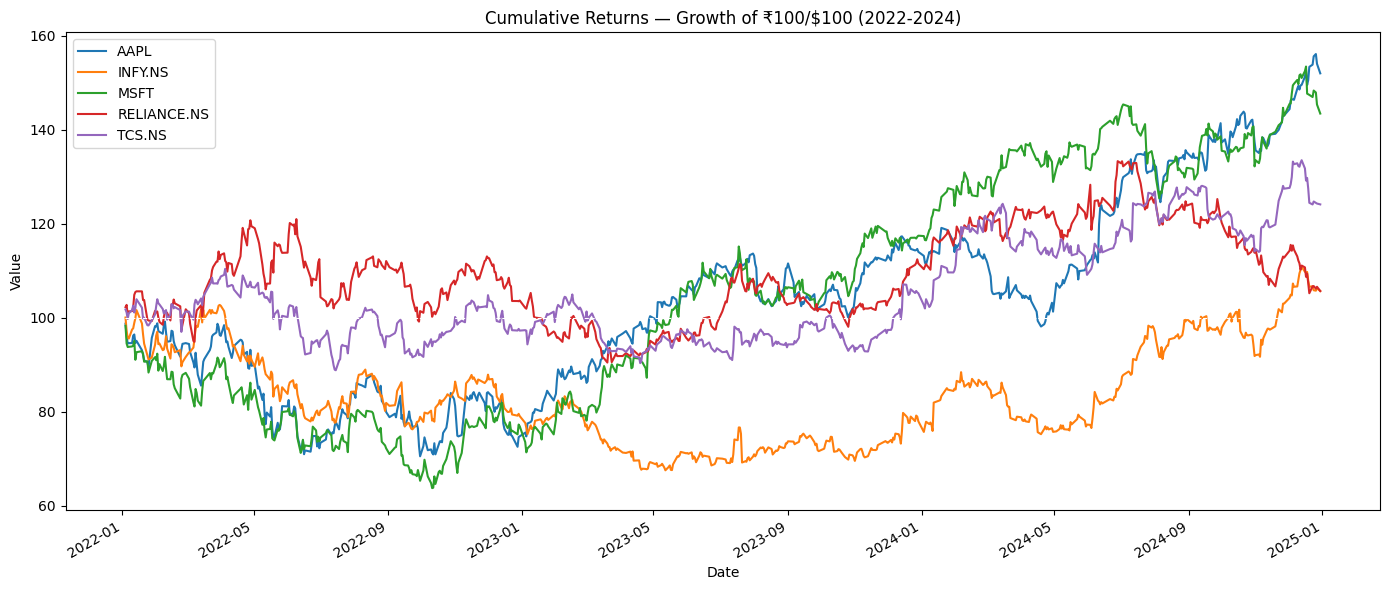

In [6]:
~~~~cumulative = (1 + returns).cumprod() * 100

cumulative.plot(figsize=(14, 6),
                title='Cumulative Returns — Growth of ₹100/$100 (2022-2024)')
plt.ylabel('Value')
plt.axhline(100, color='white', linewidth=0.8, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()